# Starting the DeepLearning

In [1]:
import torch 

## Introduction of tensor 

In [2]:
# 1.  Scalar Tensor 

a = 2 
scalar =  torch.tensor(42)
print("Scalar tensor:",scalar)
print("Scalar diamension:",scalar.ndim)
print("Shape of Scalar tensor:",scalar.shape)

Scalar tensor: tensor(42)
Scalar diamension: 0
Shape of Scalar tensor: torch.Size([])


In [3]:
# 2. Vector tensor 1D

vector  =  torch.tensor([2,5,6])
print("Vector tensor:",vector)
print("Vector diamension:",vector.ndim)
print("Shape of Vector tensor:",vector.shape)


Vector tensor: tensor([2, 5, 6])
Vector diamension: 1
Shape of Vector tensor: torch.Size([3])


In [4]:
## Matrix 2D
matrix =  torch.tensor([[3,8],
                        [8,5]])
print("matrix tensor:",matrix)
print("matrix diamension:",matrix.ndim)
print("Shape of matrix tensor:",matrix.shape)

matrix tensor: tensor([[3, 8],
        [8, 5]])
matrix diamension: 2
Shape of matrix tensor: torch.Size([2, 2])


In [5]:
## Tensor 3D
Tensor =  torch.tensor([[[3,4,8],[8,2,5]],[[2,6,4],[3,5,5]],[[3,2,3],[5,4,3]]])
print("tensor tensor:",Tensor)
print("tensor diamension:",Tensor.ndim)
print("Shape of tensor:",Tensor.shape)

tensor tensor: tensor([[[3, 4, 8],
         [8, 2, 5]],

        [[2, 6, 4],
         [3, 5, 5]],

        [[3, 2, 3],
         [5, 4, 3]]])
tensor diamension: 3
Shape of tensor: torch.Size([3, 2, 3])


In [11]:
## GPU acceleration 
if torch.cuda.is_available():
    gpu_tensor = vector.to('cuda')
    print('Tensor on GPU:',gpu_tensor)
else:
    print('Cuda not available')

Tensor on GPU: tensor([2, 5, 6], device='cuda:0')


In [20]:
##  Tensor Properties

print("Data type of matrix:",matrix.dtype)
print("Device of Tensor:",matrix.device)
print("Device of Tensor:",gpu_tensor.device)

## Tensor on Gpu == CuDa
print("Device of Tensor:",matrix.is_cuda)
print("Device of Tensor:",gpu_tensor.is_cuda)

print("Size",matrix.size())

## how to find the number of elements

print("number of elements:",matrix.numel())


Data type of matrix: torch.int64
Device of Tensor: cpu
Device of Tensor: cuda:0
Device of Tensor: False
Device of Tensor: True
Size torch.Size([2, 2])
number of elements: 4


Device of Tensor: cpu
Device of Tensor: cuda:0


In [16]:
!nvidia-smi

Wed Mar  4 17:36:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P8              6W /   80W |    1006MiB /   4096MiB |     29%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Indexing Tensors

In [22]:
# Accessing elements in a tensor 

'''
tensor[row,columns]
'''

'\ntensor[row,columns]\n'

In [159]:
import torch

Access_elements = torch.tensor([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("Dimensions:", Access_elements.ndim)
print("Shape:", Access_elements.shape)

# Access specific elements (row, column)

print("Element at [0,1]:", Access_elements[0, 1])  # Row 0, Column 1
print("Element at [0,0]:", Access_elements[0, 0])  # Row 0, Column 0
print("Element at [2,0]:", Access_elements[2, 0])  # Row 2, Column 0
print("Element at [1,2]:", Access_elements[1, 2])  # Row 1, Column 2
print("Element at [2,2]:", Access_elements[2, 2])  # Row 2, Column 2


Dimensions: 2
Shape: torch.Size([3, 3])
Element at [0,1]: tensor(20)
Element at [0,0]: tensor(10)
Element at [2,0]: tensor(70)
Element at [1,2]: tensor(60)
Element at [2,2]: tensor(90)


In [160]:
##  Access first row
Access_elements[0]

tensor([10, 20, 30])

In [161]:
##  Access first col
Access_elements[:,0] ## Zero index of the all the cols

tensor([10, 40, 70])

# slicing techniques

1. Access_elements[:,1]   # entire column
2. Access_elements[1,:]   # entire row
3. Access_elements[:2,:2] # sub-matrix
4. Access_elements[-1]    # last row
5. Access_elements[::-1]  # reverse tensor

In [162]:
print('First two row:',Access_elements[:2])

First two row: tensor([[10, 20, 30],
        [40, 50, 60]])


In [163]:
print(Access_elements)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])


In [164]:
## First two columns
print('First two row:',Access_elements[:,:2])

First two row: tensor([[10, 20],
        [40, 50],
        [70, 80]])


In [165]:
## Pickup specific columns
print("Specific columns:", Access_elements[1, 1:3])  
# Access row 1 (second row) and columns from index 1 to 2
  

Specific columns: tensor([50, 60])


In [166]:
print(Access_elements)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])


In [167]:
## Fancy indexing
# 0,1 ---> 20 
# 2,2 ---> 90
select_elements = Access_elements[[0,2],[1,2]] 
print(select_elements)

tensor([20, 90])


1. row[1,2] Row indices is used to  select the position 
2. col[2,0] col indices it used to pick the element

✅ This only work when we do pick two unique element from various region [[0,2],[1,2]]

real way of saying

1. Row indices = [1,2] → used to select the row positions.
2. Column indices = [2,0] → used to select the column positions.
3. PyTorch pairs them position-by-position:
   (1,2) and (2,0)
4. These coordinates are used to pick the elements from the tensor.

## Boolean Indexing

In [168]:
print(Access_elements)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])


In [169]:
## it show the Boolean  values  which greater then 50 is True lesser then 50 False
mask = Access_elements > 50
print(mask)
print(Access_elements[mask])


tensor([[False, False, False],
        [False, False,  True],
        [ True,  True,  True]])
tensor([60, 70, 80, 90])


## Changing index value Via Indexing

In [170]:
print(Access_elements)
Access_elements[1,0] = 100
print('*'*40)
print(Access_elements)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])
****************************************
tensor([[ 10,  20,  30],
        [100,  50,  60],
        [ 70,  80,  90]])


In [171]:
Access_elements[0,:] = torch.tensor([1000,2000,3000])
print(Access_elements)

tensor([[1000, 2000, 3000],
        [ 100,   50,   60],
        [  70,   80,   90]])


In [ ]:
Access_elements[[1,1],[1,2]] = torch.tensor([500,600])
print(Access_elements)

tensor([[1000, 2000, 3000],
        [ 100,  500,  600],
        [  70,   80,   90]])


In [181]:
indice = torch.tensor([0,2])
select_row=torch.index_select(Access_elements,dim=0,index=indice)
print(select_row)

tensor([[1000, 2000, 3000],
        [  70,   80,   90]])


In [182]:
## using tensor with steps
print(Access_elements[:,::2])


tensor([[1000, 3000],
        [ 100,  600],
        [  70,   90]])


In [184]:
## print(Access_elements[::-1]) this method  not in tensor
torch.flip(Access_elements,dims=(0,))

tensor([[  70,   80,   90],
        [ 100,  500,  600],
        [1000, 2000, 3000]])

In [187]:
torch.flip(Access_elements,dims=(1,))

tensor([[3000, 2000, 1000],
        [ 600,  500,  100],
        [  90,   80,   70]])

# USing Random Number to Create  noise image

In [189]:
random_tensor =  torch.rand(5)
print(random_tensor)
print(random_tensor.ndim)

tensor([0.1460, 0.8345, 0.9636, 0.8662, 0.3838])
1


In [ ]:
matrix_random =  torch.rand(2,5,3)
print(matrix_random)
print(matrix_random.ndim)
print(matrix_random.shape)

tensor([[[0.2460, 0.6146, 0.0175],
         [0.4591, 0.4144, 0.6256],
         [0.8786, 0.6505, 0.6236],
         [0.7012, 0.6604, 0.1386],
         [0.4754, 0.0203, 0.9436]],

        [[0.3232, 0.8515, 0.3034],
         [0.4452, 0.1018, 0.8481],
         [0.8813, 0.9808, 0.0542],
         [0.6656, 0.2241, 0.9782],
         [0.9727, 0.6928, 0.9298]]])
3
torch.Size([2, 5, 3])


In [204]:
##  seed for the fixed valued

torch.manual_seed(42)
random_tensor =  torch.rand(5)
print(random_tensor)

tensor([0.8823, 0.9150, 0.3829, 0.9593, 0.3904])


## Trying to genrate the Random integer

In [ ]:
# torch.randint(low,high,size)

int_tensor = torch.randint(1,20,(2,3,5))
print(int_tensor)

tensor([[[15, 19, 14,  2, 16],
         [12, 15,  6, 16,  5],
         [11, 17, 12,  1,  6]],

        [[13,  7, 16,  9, 16],
         [19,  9,  5, 14,  3],
         [15,  2, 19,  4, 12]]])


In [215]:
# generate random number from normal distribution 

#  Torch.normal(mean,std,size)

nor_ten = torch.normal(1,2,(5,))
print(nor_ten)

tensor([ 2.8768,  1.8009,  3.1458, -2.5059, -0.9963])


## Creating noise image using pytorch

In [216]:
import matplotlib.pyplot as plt

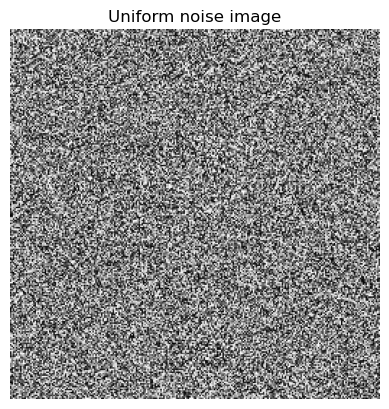

In [221]:
uniform_noise= torch.rand(256,256)
plt.imshow(uniform_noise,cmap='grey')
plt.title("Uniform noise image")
plt.axis("Off")
plt.show()

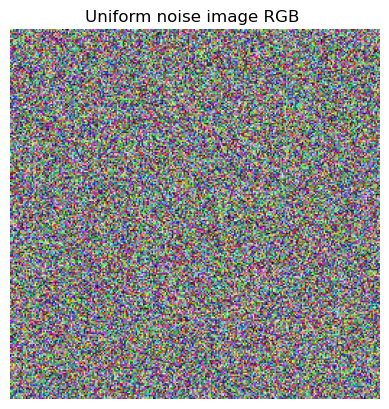

In [ ]:
uniform_noise_rgb= torch.rand((256,256,3))
plt.imshow(uniform_noise_rgb.numpy())
plt.title("Uniform noise image RGB ")
plt.axis("Off")
plt.show()

In [227]:
print("shape;",uniform_noise_rgb.shape)
print('data types:',uniform_noise_rgb.dtype)
print("min value:",torch.min(uniform_noise_rgb))
print("max values:",torch.max(uniform_noise_rgb))
print("Dimension:",uniform_noise_rgb.ndim)

shape; torch.Size([256, 256, 3])
data types: torch.float32
min value: tensor(2.0862e-06)
max values: tensor(1.0000)
Dimension: 3
